In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("ops_sensor_log_dirty.csv")

# Dataset information
print("DATASET INFORMATION")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe(include='all'))

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB
None

STATISTICAL SUMMARY
                  timestamp          Zone      Shift  Pressure_PSI  \
count                  5015          4984       4962   4975.000000   
unique                 5000            15          3           NaN   
top     2026-06-29 09:24:00  Zone_Central  Afternoon           NaN   
freq                      2           996       1715           NaN   
mean                    NaN           NaN        NaN    255.254281   
std                   

In [2]:
def clean_ops_data(df):

    df = df.copy()

    # -------------------------------------------------
    # 1. Convert timestamps to datetime
    # -------------------------------------------------
    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        errors='coerce'
    )

    # -------------------------------------------------
    # 2. Handle missing values
    # -------------------------------------------------

    # Fill missing categorical values with mode
    df['Zone'] = df['Zone'].fillna(df['Zone'].mode()[0])
    df['Shift'] = df['Shift'].fillna(df['Shift'].mode()[0])

    # Interpolate numerical sensor values
    numeric_cols = [
        'Pressure_PSI',
        'Temperature_C',
        'Flow_Rate_LPM'
    ]

    df[numeric_cols] = (
        df[numeric_cols]
        .interpolate(method='linear')
    )

    # -------------------------------------------------
    # 3. Remove duplicates
    # -------------------------------------------------
    df = df.drop_duplicates()

    # -------------------------------------------------
    # 4. Standardize categorical columns
    # -------------------------------------------------
    df['Zone'] = (
        df['Zone']
        .str.strip()
        .str.title()
    )

    df['Shift'] = (
        df['Shift']
        .str.strip()
        .str.title()
    )

    # -------------------------------------------------
    # 5. Remove impossible readings
    # -------------------------------------------------

    df = df[
        (df['Pressure_PSI'] >= 0) &
        (df['Pressure_PSI'] <= 500)
    ]

    df = df[
        (df['Temperature_C'] >= -20) &
        (df['Temperature_C'] <= 150)
    ]

    df = df[
        (df['Flow_Rate_LPM'] >= 0) &
        (df['Flow_Rate_LPM'] <= 2000)
    ]

    return df


# Apply cleaning
clean_df = clean_ops_data(df)

print("Original Shape:", df.shape)
print("Cleaned Shape:", clean_df.shape)

Original Shape: (5015, 6)
Cleaned Shape: (4929, 6)


In [3]:
# Set timestamp as index
clean_df = clean_df.set_index('timestamp')

# Hourly averages
hourly_data = (
    clean_df['Pressure_PSI']
    .resample('H')
    .mean()
)

# 24-hour rolling average
rolling_avg_24h = (
    hourly_data
    .rolling(window=24)
    .mean()
)

print("Hourly Data")
print(hourly_data.head())

print("\n24 Hour Rolling Average")
print(rolling_avg_24h.head())

C:\Users\Mr IP\AppData\Local\Temp\ipykernel_6844\431580499.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('H')


Hourly Data
timestamp
2026-01-07 09:00:00    139.019377
2026-01-07 10:00:00           NaN
2026-01-07 11:00:00           NaN
2026-01-07 12:00:00           NaN
2026-01-07 13:00:00           NaN
Freq: h, Name: Pressure_PSI, dtype: float64

24 Hour Rolling Average
timestamp
2026-01-07 09:00:00   NaN
2026-01-07 10:00:00   NaN
2026-01-07 11:00:00   NaN
2026-01-07 12:00:00   NaN
2026-01-07 13:00:00   NaN
Freq: h, Name: Pressure_PSI, dtype: float64


In [4]:
summary_table = (
    clean_df
    .groupby(['Shift', 'Zone'])
    .agg({
        'Pressure_PSI': ['mean', 'max', 'min'],
        'Temperature_C': ['mean', 'max', 'min'],
        'Flow_Rate_LPM': ['mean', 'max', 'min']
    })
)

print(summary_table)

                       Pressure_PSI                         Temperature_C  \
                               mean         max         min          mean   
Shift     Zone                                                              
Afternoon North Zone     224.601162  277.069521  172.132803     77.141482   
          South Zone     219.438805  250.847309  188.030301     60.482426   
          Z_North        233.718874  245.592898  221.844850     56.403984   
          Z_South        230.818123  275.888794  185.747451     55.924453   
          Zone North     205.806646  275.115651  137.049517     79.939819   
          Zone South     157.908147  157.908147  157.908147     54.022160   
          Zone-North     194.568814  235.623552  152.333306     68.963250   
          Zone_Central   199.420166  279.941700    0.000000     64.747675   
          Zone_East      204.083474  278.852932  120.863767     64.529687   
          Zone_North     202.642207  279.854523    0.000000     63.980990   

Matplotlib is building the font cache; this may take a moment.


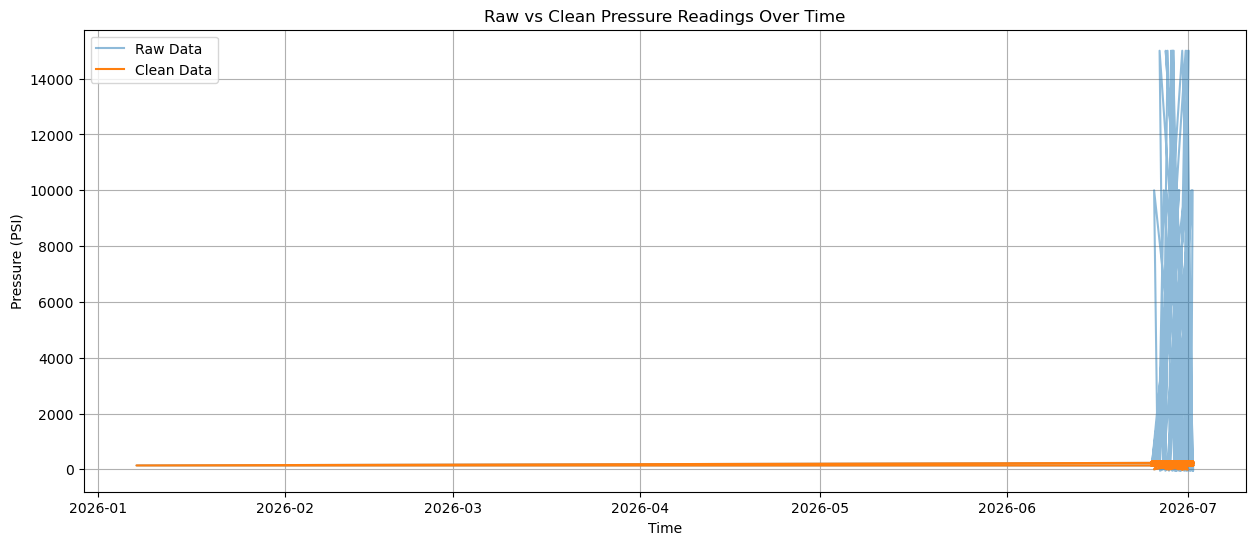

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Raw data
plt.plot(
    pd.to_datetime(df['timestamp']),
    df['Pressure_PSI'],
    label='Raw Data',
    alpha=0.5
)

# Clean data
plt.plot(
    clean_df.index,
    clean_df['Pressure_PSI'],
    label='Clean Data'
)

plt.title(
    'Raw vs Clean Pressure Readings Over Time'
)

plt.xlabel('Time')
plt.ylabel('Pressure (PSI)')
plt.legend()
plt.grid(True)

plt.show()